# Feature Transformation Pipeline


## Imports

In [28]:
import json
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV, VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

from risk_calculator import RiskCalculator

## Paths

In [29]:
MERGED_DATA_PATH = "../data/merged/multi_turn_data.csv"
PROCESSED_DIR    = "../data/processed"
FIGURES_DIR      = "../reports/figures"
SCALER_SAVE_PATH = "../models/scaler.pkl"

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR,   exist_ok=True)
os.makedirs(os.path.dirname(SCALER_SAVE_PATH), exist_ok=True)

## Load Data & Recompute Risks

In [30]:
df = pd.read_csv(MERGED_DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (2650, 9)


,conv_id,turn_id,label,toxicity_score,threat_score,topic_drift_score,cumulative_drift,drift_acceleration,post_refusal
0,0,0,0,0.024668,0.001102,0.0000,0.0000,0.0,1.0
1,0,1,1,0.036629,0.001537,0.2665,0.2665,0.0,1.0
2,1,0,0,0.031880,0.000943,0.0000,0.0000,0.0,1.0
3,1,1,1,0.057176,0.002084,0.2815,0.2815,0.0,1.0
4,2,0,1,0.002470,0.000771,0.0000,0.0000,0.0,0.0


In [31]:
# Fixed recompute_risks: single-pass prev_progressive (no index misalignment bug)
def recompute_risks(df: pd.DataFrame, calc: RiskCalculator) -> pd.DataFrame:
    df = df.sort_values(["conv_id", "turn_id"]).reset_index(drop=True)

    interaction_list = []
    pattern_list     = []
    progressive_list = []
    prev_prog_list   = []

    for _cid, group in df.groupby("conv_id", sort=False):
        prev = 0.0
        for _, row in group.iterrows():
            interaction = calc.compute_interaction_risk(row)
            pattern     = calc.compute_pattern_risk(row)
            prog        = calc.calculate_progressive_risk(row, prev)

            interaction_list.append(interaction)
            pattern_list.append(pattern)
            progressive_list.append(prog)
            prev_prog_list.append(prev)   # record BEFORE updating
            prev = prog

    df["interaction_risk"] = interaction_list
    df["pattern_risk"]     = pattern_list
    df["progressive_risk"] = progressive_list
    df["prev_progressive"] = prev_prog_list
    return df

In [32]:
params_path = "../config/optimized_params_risk.json"
if os.path.exists(params_path):
    with open(params_path) as f:
        params = json.load(f)
    print("Using optimised risk params")
else:
    params = {}
    print("Using default risk params")

# Params = {
#     'alpha': np.float64(0.5555555555555556),
#     'beta':  np.float64(0.22222222222222227),
#     'gamma': np.float64(0.22222222222222227),
#     'inter_alpha':   np.float64(0.22222222222222227),
#     'inter_beta':    np.float64(0.5555555555555556),
#     'inter_gamma':   np.float64(0.22222222222222227),
#     'pattern_alpha': np.float64(0.16666666666666669),
#     'pattern_beta':  np.float64(0.6666666666666667),
#     'pattern_gamma': np.float64(0.16666666666666669),
# }
calc = RiskCalculator(**params)
df   = recompute_risks(df, calc)
print("Shape after recompute:", df.shape)
df.head()

Using optimised risk params
Shape after recompute: (2650, 13)


,conv_id,turn_id,label,toxicity_score,threat_score,topic_drift_score,cumulative_drift,drift_acceleration,post_refusal,interaction_risk,pattern_risk,progressive_risk,prev_progressive
0,0,0,0,0.024668,0.001102,0.0000,0.0000,0.0,1.0,0.026030,0.000000,0.0165,0.0000
1,0,1,1,0.036629,0.001537,0.2665,0.2665,0.0,1.0,0.034939,0.118770,0.0289,0.0165
2,1,0,0,0.031880,0.000943,0.0000,0.0000,0.0,1.0,0.031293,0.000000,0.0199,0.0000
3,1,1,1,0.057176,0.002084,0.2815,0.2815,0.0,1.0,0.050190,0.125455,0.0399,0.0199
4,2,0,1,0.002470,0.000771,0.0000,0.0000,0.0,0.0,0.002015,0.000000,0.0013,0.0000


## Define Features & Check Ranges
Shows the scale problem before fixing it.

In [33]:
# No duplicates in this list
feature_cols = [
    "toxicity_score", "threat_score",
    "topic_drift_score", "cumulative_drift", "drift_acceleration",
    "post_refusal",
    "interaction_risk", "pattern_risk", "progressive_risk", "prev_progressive",
]

missing = [c for c in feature_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

print("Feature ranges BEFORE scaling:")
df[df.columns].describe().loc[["min", "max", "mean", "std"]].T.round(5)

Feature ranges BEFORE scaling:


,min,max,mean,std
conv_id,0.00000,1105.00000,532.49849,321.66144
turn_id,0.00000,10.00000,1.35509,1.48820
label,0.00000,1.00000,0.33849,0.47329
toxicity_score,0.00014,0.98186,0.03210,0.06268
threat_score,0.00057,0.95814,0.01017,0.07036
topic_drift_score,0.00000,1.01740,0.22256,0.21942
cumulative_drift,0.00000,1.10120,0.28428,0.26980
drift_acceleration,-0.84310,0.77540,-0.01355,0.11826
post_refusal,0.00000,1.00000,0.22717,0.41908
interaction_risk,0.00025,0.95487,0.02795,0.05570


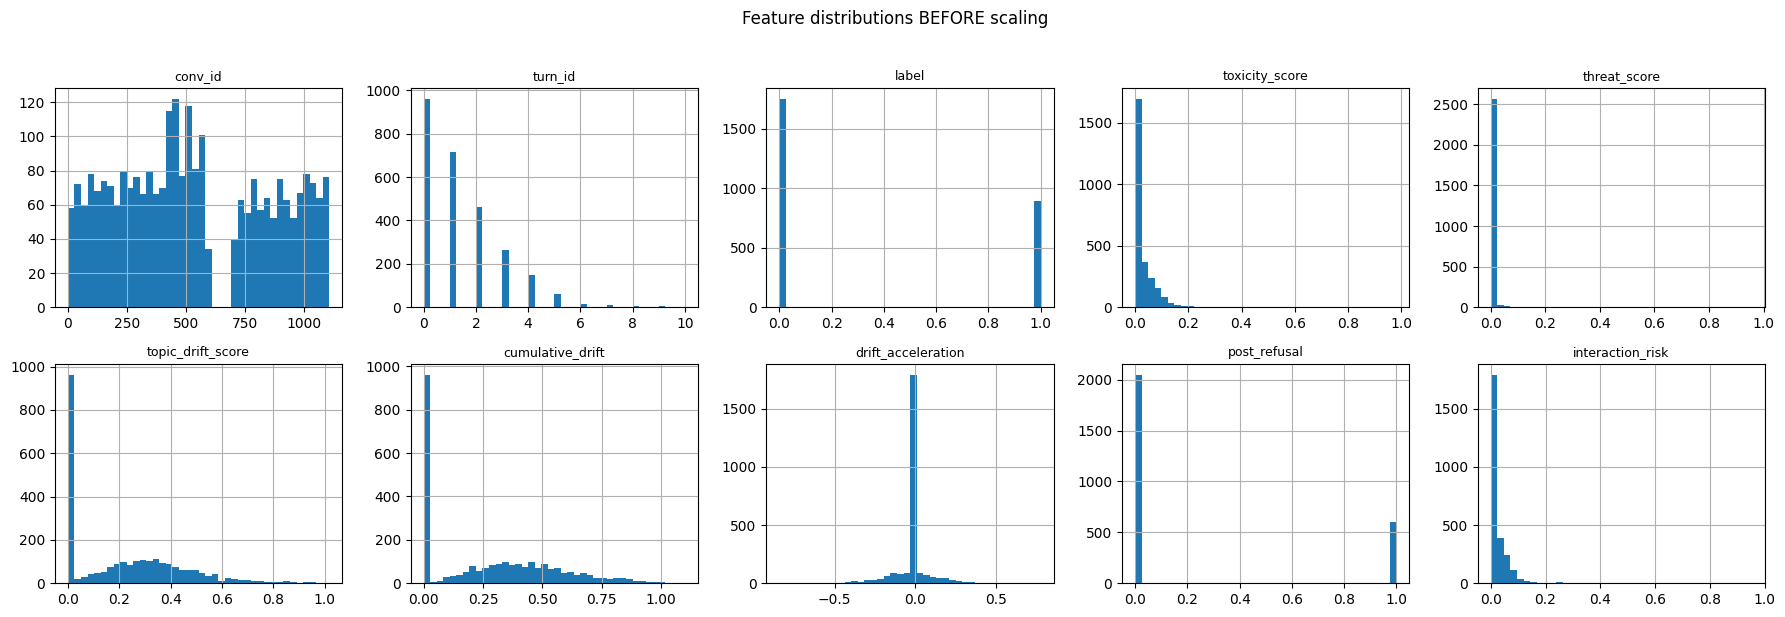

In [34]:
# Visualise the scale problem
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, col in zip(axes.flatten(), df.columns):
    df[col].hist(bins=40, ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
plt.suptitle("Feature distributions BEFORE scaling", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/distributions_before_scaling.png", bbox_inches="tight")
plt.show()

## Step 1 — Train / Val / Test Split


In [35]:
df_indexed = df[["conv_id", "turn_id"] + feature_cols + ["label"]].reset_index(drop=True)

idx_all = df_indexed.index.tolist()

idx_train, idx_temp = train_test_split(
    idx_all, test_size=0.40, random_state=42, stratify=df_indexed["label"]
)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, random_state=42,
    stratify=df_indexed.loc[idx_temp, "label"]
)

X_train = df_indexed.loc[idx_train, feature_cols].reset_index(drop=True)
X_val   = df_indexed.loc[idx_val,   feature_cols].reset_index(drop=True)
X_test  = df_indexed.loc[idx_test,  feature_cols].reset_index(drop=True)

y_train = df_indexed.loc[idx_train, "label"].reset_index(drop=True)
y_val   = df_indexed.loc[idx_val,   "label"].reset_index(drop=True)
y_test  = df_indexed.loc[idx_test,  "label"].reset_index(drop=True)

# Keep conv/turn ids for saving later
meta_train = df_indexed.loc[idx_train, ["conv_id", "turn_id"]].reset_index(drop=True)
meta_val   = df_indexed.loc[idx_val,   ["conv_id", "turn_id"]].reset_index(drop=True)
meta_test  = df_indexed.loc[idx_test,  ["conv_id", "turn_id"]].reset_index(drop=True)

print(f"Train : {X_train.shape}   label balance: {y_train.mean():.3f}")
print(f"Val   : {X_val.shape}   label balance: {y_val.mean():.3f}")
print(f"Test  : {X_test.shape}   label balance: {y_test.mean():.3f}")

Train : (1590, 10)   label balance: 0.338
Val   : (530, 10)   label balance: 0.340
Test  : (530, 10)   label balance: 0.338


## Step 2 — Scaling (RobustScaler)


In [36]:
scaler = RobustScaler()

features= [col for col in X_train.columns if col not in ["conv_id", "turn_id"]]

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=features
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=features
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=features
)

# Save scaler for inference
joblib.dump(scaler, SCALER_SAVE_PATH)
print(f"Scaler saved → {SCALER_SAVE_PATH}")

print("\nFeature ranges AFTER scaling (train):")
X_train_scaled.describe().loc[["min", "max", "mean", "std"]].T.round(3)

Scaler saved → ../models/scaler.pkl

Feature ranges AFTER scaling (train):


,min,max,mean,std
toxicity_score,-0.244,22.586,0.540,1.645
threat_score,-0.280,666.221,7.727,55.932
topic_drift_score,-0.521,2.293,0.068,0.601
cumulative_drift,-0.535,1.682,0.046,0.572
drift_acceleration,-0.820,0.775,-0.012,0.114
post_refusal,0.000,1.000,0.221,0.415
interaction_risk,-0.317,30.355,0.628,2.038
pattern_risk,-2.561,4.548,0.214,0.735
progressive_risk,-0.421,25.039,0.572,1.848
prev_progressive,-0.217,24.067,0.774,2.079


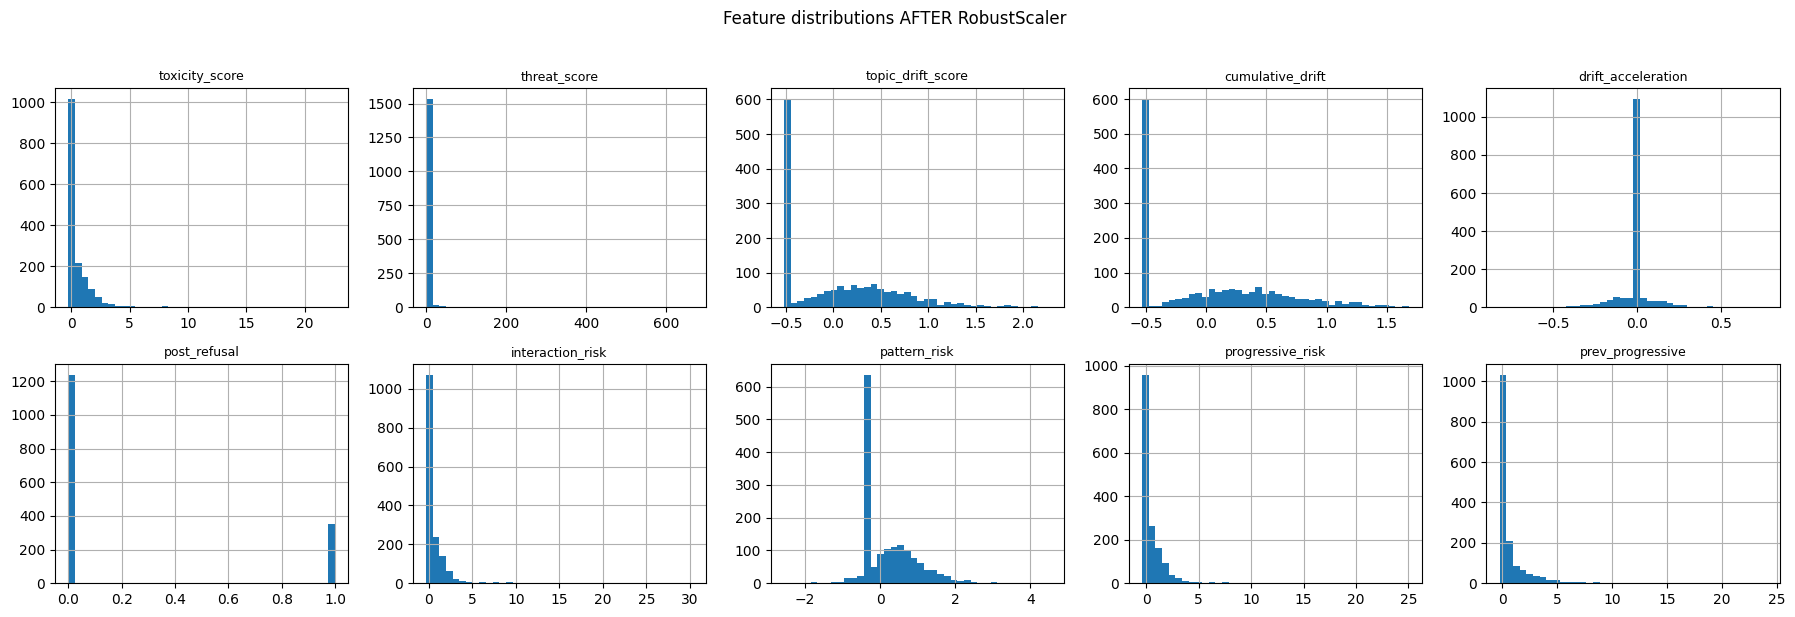

In [37]:
# Visualise distributions after scaling
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, col in zip(axes.flatten(), feature_cols):
    X_train_scaled[col].hist(bins=40, ax=ax)
    ax.set_title(col, fontsize=9)
plt.suptitle("Feature distributions AFTER RobustScaler", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/distributions_after_scaling.png", bbox_inches="tight")
plt.show()

In [38]:
def add_smoothing_features(df):
    for col in ["toxicity_score", "threat_score", "interaction_risk", "pattern_risk"]:

        df[f"{col}_ema3"] = (
            df.groupby("conv_id")[col]
            .transform(lambda x: x.ewm(span=3, adjust=False).mean())
        )

        df[f"{col}_rolling3_mean"] = (
            df.groupby("conv_id")[col]
            .transform(lambda x: x.rolling(3, min_periods=1).mean())
        )

        df[f"{col}_rolling3_max"] = (
            df.groupby("conv_id")[col]
            .transform(lambda x: x.rolling(3, min_periods=1).max())
        )

    return df
def add_refusal_context(df):

    g = df.groupby("conv_id")

    df["refusal_seen_so_far"] = g["post_refusal"].cumsum()
    df["after_refusal_flag"] = df["refusal_seen_so_far"] > 0

    return df
def add_escalation_features(df):

    df["toxicity_diff"] = df.groupby("conv_id")["toxicity_score"].diff().fillna(0)
    df["threat_diff"] = df.groupby("conv_id")["threat_score"].diff().fillna(0)

    df["toxicity_accel"] = df.groupby("conv_id")["toxicity_diff"].diff().fillna(0)

    df["risk_slope_3"] = (
        df.groupby("conv_id")["interaction_risk"]
        .transform(lambda x: x.diff().rolling(3, min_periods=1).mean())
        .fillna(0)
    )

    return df
def add_context_features(df):

    g = df.groupby("conv_id")

    df["max_toxicity_so_far"] = g["toxicity_score"].cummax()
    df["max_threat_so_far"] = g["threat_score"].cummax()

    df["mean_risk_so_far"] = (
        g["interaction_risk"]
        .expanding()
        .mean()
        .reset_index(level=0, drop=True)
    )

    return df
def add_shape_features(df):

    g = df.groupby("conv_id")

    df["early_high_risk"] = (
        g["interaction_risk"]
        .transform(lambda x: x.head(3).max())
    )

    df["late_risk_increase"] = (
        g["interaction_risk"]
        .transform(lambda x: x.tail(3).mean())
    )

    df["risk_growth_ratio"] = (
        df["late_risk_increase"] /
        (df["early_high_risk"] + 1e-6)
    )

    return df
def build_features(df):

    df = df.sort_values(["conv_id", "turn_id"])

    df = add_smoothing_features(df)
    df = add_escalation_features(df)
    df = add_context_features(df)
    df = add_shape_features(df)
    df = add_refusal_context(df)

    return df

X_train_scaled = build_features(df_indexed.loc[idx_train, ["conv_id", "turn_id"] + feature_cols])
X_val_scaled   = build_features(df_indexed.loc[idx_val, ["conv_id", "turn_id"] + feature_cols])
X_test_scaled  = build_features(df_indexed.loc[idx_test, ["conv_id", "turn_id"] + feature_cols])


# remove ["conv_id", "turn_id"] from feature set for modeling
X_train_scaled = X_train_scaled.drop(columns=["conv_id", "turn_id"])
X_val_scaled   = X_val_scaled.drop(columns=["conv_id", "turn_id"])
X_test_scaled  = X_test_scaled.drop(columns=["conv_id", "turn_id"])


In [39]:
TRANSFORMS = {
    "toxicity_score": "log1p",
    "threat_score": "log1p",
    "interaction_risk": "log1p",

    "toxicity_score_ema3": "log1p",
    "toxicity_score_rolling3_mean": "log1p",
    "toxicity_score_rolling3_max": "log1p",

    "threat_score_ema3": "log1p",
    "threat_score_rolling3_mean": "log1p",
    "threat_score_rolling3_max": "log1p",

    "toxicity_diff": "square",
    "threat_diff": "square",
    "toxicity_accel": "square",

    "max_toxicity_so_far": "log1p",
    "max_threat_so_far": "log1p",

    "risk_growth_ratio": "log1p",

    "topic_drift_score": "binarize",
    "cumulative_drift": "binarize",
    "drift_acceleration": "square",

    "post_refusal": "log1p",

    "pattern_risk": "binarize",
    "prev_progressive": "binarize",

    "interaction_risk_ema3": "log1p",
    "interaction_risk_rolling3_mean": "log1p",
    "interaction_risk_rolling3_max": "log1p",

    "pattern_risk_ema3": "binarize",
    "pattern_risk_rolling3_mean": "binarize",
    "pattern_risk_rolling3_max": "binarize",

    "risk_slope_3": "square",

    "mean_risk_so_far": "log1p",
    "late_risk_increase": "log1p",

    "refusal_seen_so_far": "log1p",
    "after_refusal_flag": "log1p",
}


In [40]:
def apply_transform(series, transform):

    if transform == "log1p":
        return np.log1p(np.maximum(series, 0))

    elif transform == "square":
        return np.square(series)

    return series

In [41]:
def engineer_features(df):

    df = df.copy()

    for feature, transform in TRANSFORMS.items():

        if feature not in df.columns:
            continue

        df[f"{feature}_trans"] = apply_transform(
            df[feature],
            transform
        )

    return df

In [42]:
# X_train_scaled = engineer_features(X_train_scaled)
# X_val_scaled = engineer_features(X_val_scaled)
# X_test_scaled = engineer_features(X_test_scaled)

## Step 3 — Variance Filter
Remove features with near-zero variance (they carry no information).

In [43]:
# Ensure identifier columns are not used as features
X_train_scaled = X_train_scaled.drop(columns=[c for c in ["conv_id", "turn_id"] if c in X_train_scaled.columns])

var_selector = VarianceThreshold(threshold=0.002)
var_selector.fit(X_train_scaled)  # fit on train only

selected_var = X_train_scaled.columns[var_selector.get_support()].tolist()
removed_var  = [c for c in X_train_scaled.columns if c not in selected_var]

X_train_sel = pd.DataFrame(var_selector.transform(X_train_scaled), columns=selected_var)
X_val_sel   = pd.DataFrame(var_selector.transform(X_val_scaled),   columns=selected_var)
X_test_sel  = pd.DataFrame(var_selector.transform(X_test_scaled),  columns=selected_var)

print(f"Removed (low variance): {removed_var}")
print(f"Kept ({len(selected_var)}): {selected_var}")


Removed (low variance): ['progressive_risk', 'prev_progressive', 'risk_slope_3']
Kept (31): ['toxicity_score', 'threat_score', 'topic_drift_score', 'cumulative_drift', 'drift_acceleration', 'post_refusal', 'interaction_risk', 'pattern_risk', 'toxicity_score_ema3', 'toxicity_score_rolling3_mean', 'toxicity_score_rolling3_max', 'threat_score_ema3', 'threat_score_rolling3_mean', 'threat_score_rolling3_max', 'interaction_risk_ema3', 'interaction_risk_rolling3_mean', 'interaction_risk_rolling3_max', 'pattern_risk_ema3', 'pattern_risk_rolling3_mean', 'pattern_risk_rolling3_max', 'toxicity_diff', 'threat_diff', 'toxicity_accel', 'max_toxicity_so_far', 'max_threat_so_far', 'mean_risk_so_far', 'early_high_risk', 'late_risk_increase', 'risk_growth_ratio', 'refusal_seen_so_far', 'after_refusal_flag']


## Step 4 — Correlation with Target Filter
Remove features weakly correlated with the label.

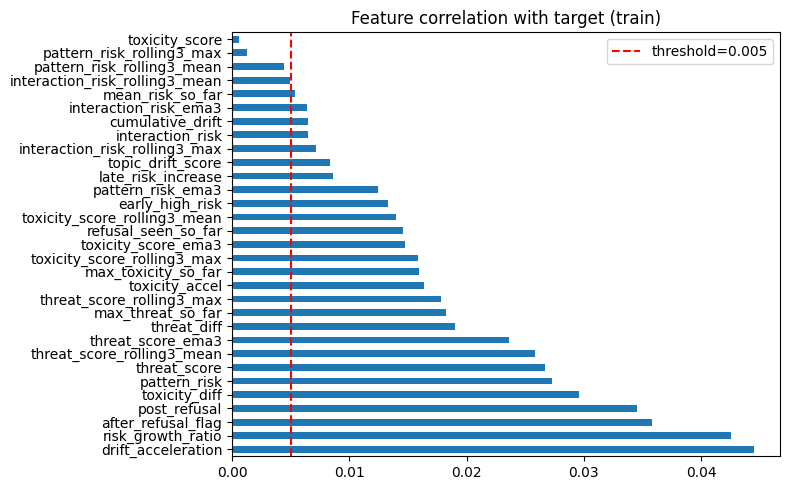

drift_acceleration                0.0445
risk_growth_ratio                 0.0426
after_refusal_flag                0.0358
post_refusal                      0.0345
toxicity_diff                     0.0296
pattern_risk                      0.0273
threat_score                      0.0267
threat_score_rolling3_mean        0.0258
threat_score_ema3                 0.0237
threat_diff                       0.0190
max_threat_so_far                 0.0183
threat_score_rolling3_max         0.0178
toxicity_accel                    0.0164
max_toxicity_so_far               0.0159
toxicity_score_rolling3_max       0.0159
toxicity_score_ema3               0.0148
refusal_seen_so_far               0.0146
toxicity_score_rolling3_mean      0.0140
early_high_risk                   0.0133
pattern_risk_ema3                 0.0124
late_risk_increase                0.0086
topic_drift_score                 0.0083
interaction_risk_rolling3_max     0.0071
interaction_risk                  0.0065
cumulative_drift

In [44]:
# Compute on TRAIN only
# drop identifier columns if present
corr_input = X_train_sel.drop(columns=[c for c in ["conv_id", "turn_id"] if c in X_train_sel.columns])
corr_with_target = corr_input.corrwith(y_train).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
corr_with_target.plot(kind="barh", ax=ax)
ax.axvline(0.005, color="red", linestyle="--", label="threshold=0.005")
ax.set_title("Feature correlation with target (train)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/feature_correlation.png")
plt.show()

print(corr_with_target.round(4).to_string())


In [45]:
CORR_THRESHOLD = 0.005

selected_corr = corr_with_target[corr_with_target > CORR_THRESHOLD].index.tolist()
removed_corr  = [c for c in X_train_sel.columns if c not in selected_corr]

X_train_sel = X_train_sel[selected_corr]
X_val_sel   = X_val_sel[selected_corr]
X_test_sel  = X_test_sel[selected_corr]

print(f"Removed (low target corr): {removed_corr}")
print(f"Kept ({len(selected_corr)}): {selected_corr}")

Removed (low target corr): ['toxicity_score', 'interaction_risk_rolling3_mean', 'pattern_risk_rolling3_mean', 'pattern_risk_rolling3_max']
Kept (27): ['drift_acceleration', 'risk_growth_ratio', 'after_refusal_flag', 'post_refusal', 'toxicity_diff', 'pattern_risk', 'threat_score', 'threat_score_rolling3_mean', 'threat_score_ema3', 'threat_diff', 'max_threat_so_far', 'threat_score_rolling3_max', 'toxicity_accel', 'max_toxicity_so_far', 'toxicity_score_rolling3_max', 'toxicity_score_ema3', 'refusal_seen_so_far', 'toxicity_score_rolling3_mean', 'early_high_risk', 'pattern_risk_ema3', 'late_risk_increase', 'topic_drift_score', 'interaction_risk_rolling3_max', 'interaction_risk', 'cumulative_drift', 'interaction_risk_ema3', 'mean_risk_so_far']


## Step 5 — Multicollinearity Removal


In [46]:
def find_correlated_features(corr_matrix: pd.DataFrame, threshold: float = 0.9):
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    pairs = []
    # columns to ignore when searching for correlated feature pairs
    ignore_cols = { "conv_id", "turn_id"}
    for col in upper.columns:
        if col in ignore_cols:
            continue
        hi = upper.index[abs(upper[col]) > threshold].tolist()
        for fc in hi:
            if fc not in ignore_cols:
                pairs.append({
                    "feature_A":   col,
                    "feature_B":   fc,
                    "correlation": round(corr_matrix.loc[col, fc], 3),
                })
    return pd.DataFrame(pairs)


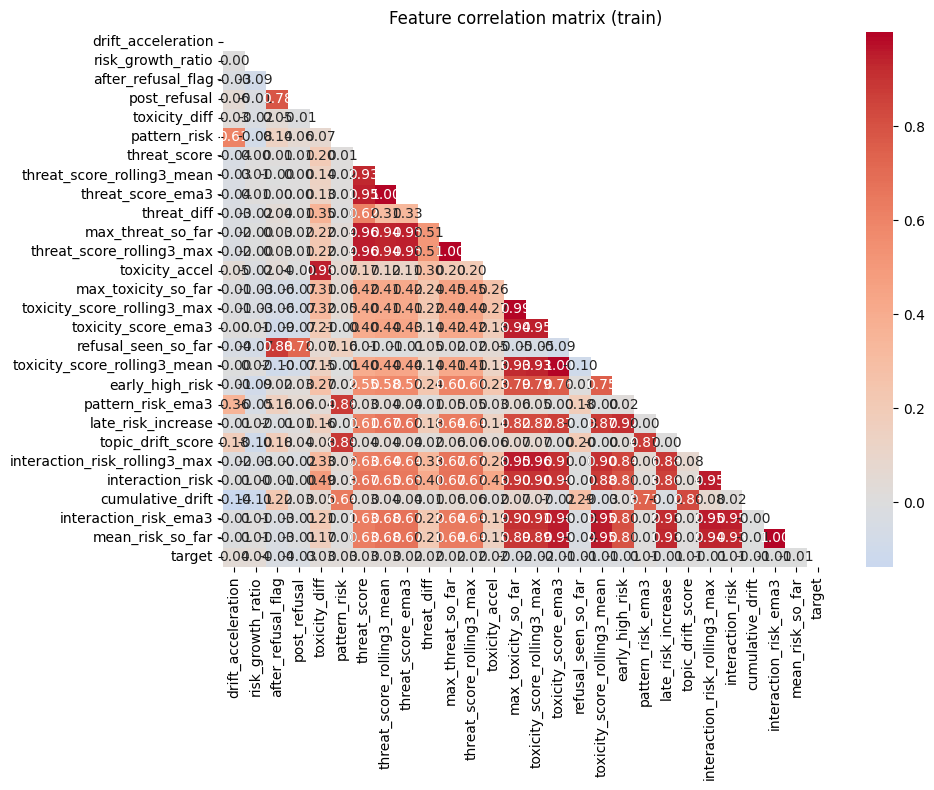


Correlation with target (sorted):
target                           1.0000
drift_acceleration               0.0445
risk_growth_ratio                0.0426
toxicity_diff                    0.0296
pattern_risk                     0.0273
threat_score                     0.0267
threat_score_rolling3_mean       0.0258
threat_score_ema3                0.0237
threat_diff                      0.0190
max_threat_so_far                0.0183
threat_score_rolling3_max        0.0178
toxicity_accel                   0.0164
pattern_risk_ema3                0.0124
topic_drift_score                0.0083
interaction_risk                 0.0065
mean_risk_so_far                -0.0054
interaction_risk_ema3           -0.0064
cumulative_drift                -0.0064
interaction_risk_rolling3_max   -0.0071
late_risk_increase              -0.0086
early_high_risk                 -0.0133
toxicity_score_rolling3_mean    -0.0140
refusal_seen_so_far             -0.0146
toxicity_score_ema3             -0.0148
toxic

In [47]:
# Compute full correlation matrix on TRAIN
df_corr = X_train_sel.copy()
df_corr["target"] = y_train.values
corr_matrix = df_corr.corr()

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, annot=True, fmt=".2f", mask=mask,
            cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature correlation matrix (train)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/correlation_heatmap.png")
plt.show()

print("\nCorrelation with target (sorted):")
print(corr_matrix["target"].sort_values(ascending=False).round(4).to_string())

In [48]:
MULTICOLLINEARITY_THRESHOLD = 0.9

correlated_pairs = find_correlated_features(corr_matrix, threshold=MULTICOLLINEARITY_THRESHOLD)
print(f"Highly correlated pairs (|r| > {MULTICOLLINEARITY_THRESHOLD}):")
print(correlated_pairs.to_string(index=False) if not correlated_pairs.empty else "None")

Highly correlated pairs (|r| > 0.9):
                    feature_A                     feature_B  correlation
   threat_score_rolling3_mean                  threat_score        0.933
            threat_score_ema3                  threat_score        0.946
            threat_score_ema3    threat_score_rolling3_mean        0.998
            max_threat_so_far                  threat_score        0.959
            max_threat_so_far    threat_score_rolling3_mean        0.940
            max_threat_so_far             threat_score_ema3        0.949
    threat_score_rolling3_max                  threat_score        0.959
    threat_score_rolling3_max    threat_score_rolling3_mean        0.940
    threat_score_rolling3_max             threat_score_ema3        0.949
    threat_score_rolling3_max             max_threat_so_far        1.000
               toxicity_accel                 toxicity_diff        0.947
  toxicity_score_rolling3_max           max_toxicity_so_far        0.994
          toxi

In [49]:
features_to_remove = set()
for _, row in correlated_pairs.iterrows():
    f1, f2  = row["feature_A"], row["feature_B"]
    # skip if one feature already marked for removal to avoid dropping both
    if f1 in features_to_remove or f2 in features_to_remove:
        continue
    c1 = abs(corr_matrix.loc[f1, "target"])
    c2 = abs(corr_matrix.loc[f2, "target"])
    # drop whichever is LESS correlated with target
    features_to_remove.add(f2 if c1 >= c2 else f1)

features_to_keep = [c for c in X_train_sel.columns if c not in features_to_remove]

X_train_sel = X_train_sel[features_to_keep]
X_val_sel   = X_val_sel[features_to_keep]
X_test_sel  = X_test_sel[features_to_keep]

print(f"Removed (multicollinear) : {features_to_remove}")
print(f"Kept ({len(features_to_keep)})             : {features_to_keep}")

Removed (multicollinear) : {'toxicity_accel', 'toxicity_score_rolling3_mean', 'interaction_risk_ema3', 'toxicity_score_ema3', 'max_threat_so_far', 'threat_score_ema3', 'interaction_risk_rolling3_max', 'mean_risk_so_far', 'late_risk_increase', 'toxicity_score_rolling3_max', 'threat_score_rolling3_mean', 'threat_score_rolling3_max'}
Kept (15)             : ['drift_acceleration', 'risk_growth_ratio', 'after_refusal_flag', 'post_refusal', 'toxicity_diff', 'pattern_risk', 'threat_score', 'threat_diff', 'max_toxicity_so_far', 'refusal_seen_so_far', 'early_high_risk', 'pattern_risk_ema3', 'topic_drift_score', 'interaction_risk', 'cumulative_drift']


## Step 6 — RFECV
Recursive Feature Elimination with Cross-Validation — finds the optimal number of features.

In [50]:
rfecv = RFECV(
    estimator = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    step      = 1,
    cv        = 5,
    scoring   = "f1_macro",
    n_jobs    = -1,
)
rfecv.fit(X_train_sel, y_train)  # fit on TRAIN only

selected_rfecv = X_train_sel.columns[rfecv.support_].tolist()
print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Selected: {selected_rfecv}")

Optimal number of features: 1
Selected: ['interaction_risk']


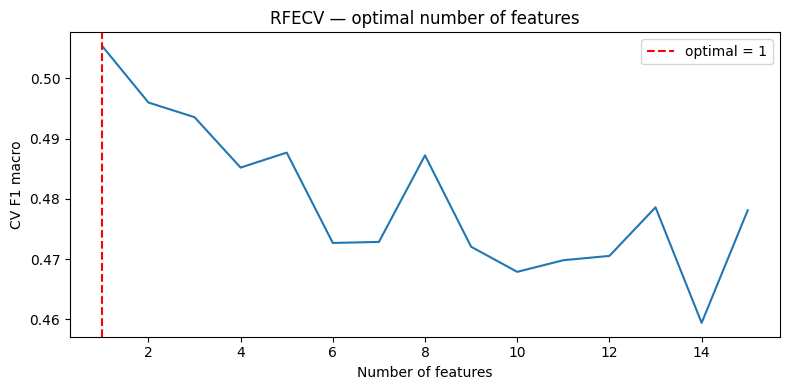

In [51]:
# RFECV curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
    rfecv.cv_results_["mean_test_score"]
)
ax.axvline(rfecv.n_features_, color="red", linestyle="--",
           label=f"optimal = {rfecv.n_features_}")
ax.set_xlabel("Number of features")
ax.set_ylabel("CV F1 macro")
ax.set_title("RFECV — optimal number of features")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rfecv_curve.png")
plt.show()

In [55]:

# X_train_final = X_train_sel[selected_rfecv]
# X_val_final   = X_val_sel[selected_rfecv]
# X_test_final  = X_test_sel[selected_rfecv]


X_train_final = X_train_sel
X_val_final   = X_val_sel
X_test_final = X_test_sel
print("Final shapes:")
print(f"  Train : {X_train_final.shape}")
print(f"  Val   : {X_val_final.shape}")
print(f"  Test  : {X_test_final.shape}")
print(f"\nFinal features: {selected_rfecv}")

Final shapes:
  Train : (1590, 15)
  Val   : (530, 15)
  Test  : (530, 15)

Final features: ['interaction_risk']


## Step 7 — Save Processed CSVs

In [56]:
def save_split(X_feat, meta, y, path):
    out = X_feat.copy()
    out["conv_id"] = meta["conv_id"].values
    out["turn_id"] = meta["turn_id"].values
    out["label"]   = y.values
    out.to_csv(path, index=False)
    print(f"Saved {path}  shape={out.shape}")

save_split(X_train_final, meta_train, y_train, f"{PROCESSED_DIR}/train.csv")
save_split(X_val_final,   meta_val,   y_val,   f"{PROCESSED_DIR}/validation.csv")
save_split(X_test_final,  meta_test,  y_test,  f"{PROCESSED_DIR}/test.csv")

# Save feature list and scaler path for model.py
feature_info = {
    "selected_features": X_train_final.columns.tolist(),
    "scaler_path":        SCALER_SAVE_PATH,
}
with open(f"../config/feature_info.json", "w") as f:
    json.dump(feature_info, f, indent=4)

print(f"\nfeature_info.json saved → {PROCESSED_DIR}/feature_info.json")
print(f"Scaler saved            → {SCALER_SAVE_PATH}")

Saved ../data/processed/train.csv  shape=(1590, 18)
Saved ../data/processed/validation.csv  shape=(530, 18)
Saved ../data/processed/test.csv  shape=(530, 18)

feature_info.json saved → ../data/processed/feature_info.json
Scaler saved            → ../models/scaler.pkl


## Summary

In [57]:
print("="*50)
print(" FEATURE TRANSFORMATION SUMMARY")
print("="*50)
print(f"  Original features   : {len(feature_cols)}")
print(f"  After variance      : {len(selected_var)}")
print(f"  After corr filter   : {len(selected_corr)}")
print(f"  After multicoll.    : {len(features_to_keep)}")
# print(f"  After RFECV         : {len(selected_rfecv)}")
print(f"  Final features      : {len(X_train_final.columns)}")
print(f"  Scaler              : RobustScaler → {SCALER_SAVE_PATH}")
print("="*50)

 FEATURE TRANSFORMATION SUMMARY
  Original features   : 10
  After variance      : 31
  After corr filter   : 27
  After multicoll.    : 15
  Final features      : 15
  Scaler              : RobustScaler → ../models/scaler.pkl
